# Module 2 — Analytics Pipeline: Modeling (Titanic)

Continues from `01_eda.ipynb`'s cleaned `titanic.csv` — no second load of the raw dataset. Stratified split, a `ColumnTransformer`/`Pipeline` fit only on the training data, three classifiers, an imbalance-handling comparison, hyperparameter tuning, a regression side-task, and a saved end-to-end pipeline.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Continue from the same cleaned data 01_eda.ipynb produced -- no second
# sns.load_dataset('titanic') call anywhere in this notebook.
df = pd.read_csv("titanic.csv")

features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X = df[features]
y = df['survived']

# Stratified split: survived is imbalanced (~62/38, see Task 1's describe()).
# A plain random split can land on train/test sets with different class
# ratios purely by chance; stratify=y keeps that same ratio in both splits
# so test-set metrics are a fair, comparable estimate across every model
# variant tried below.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

numeric_features = ['pclass', 'age', 'sibsp', 'parch', 'fare']
categorical_features = ['sex', 'embarked']

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

# ColumnTransformer + Pipeline enforces fit-on-train / transform-only-on-test
# structurally: every imputer/scaler/encoder here gets fit() only when the
# whole pipeline is fit on X_train, and only ever transform()s X_test.
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features),
])


## Training three classifiers

Logistic Regression, Decision Tree, and Random Forest, all on the identical train/test split.

In [2]:
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# clone(preprocessor) so each model gets its own unfitted copy of the
# ColumnTransformer -- fitting one pipeline must not affect the others.
log_reg = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42)),
])
dec_tree = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', DecisionTreeClassifier(random_state=42)),
])
rand_forest = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', RandomForestClassifier(random_state=42)),
])

for name, model in [('Logistic Regression', log_reg), ('Decision Tree', dec_tree), ('Random Forest', rand_forest)]:
    model.fit(X_train, y_train)
    print(name, "trained")


Logistic Regression trained
Decision Tree trained
Random Forest trained


/Users/shellzero/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shellzero/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shellzero/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shellzero/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/shellzero/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_

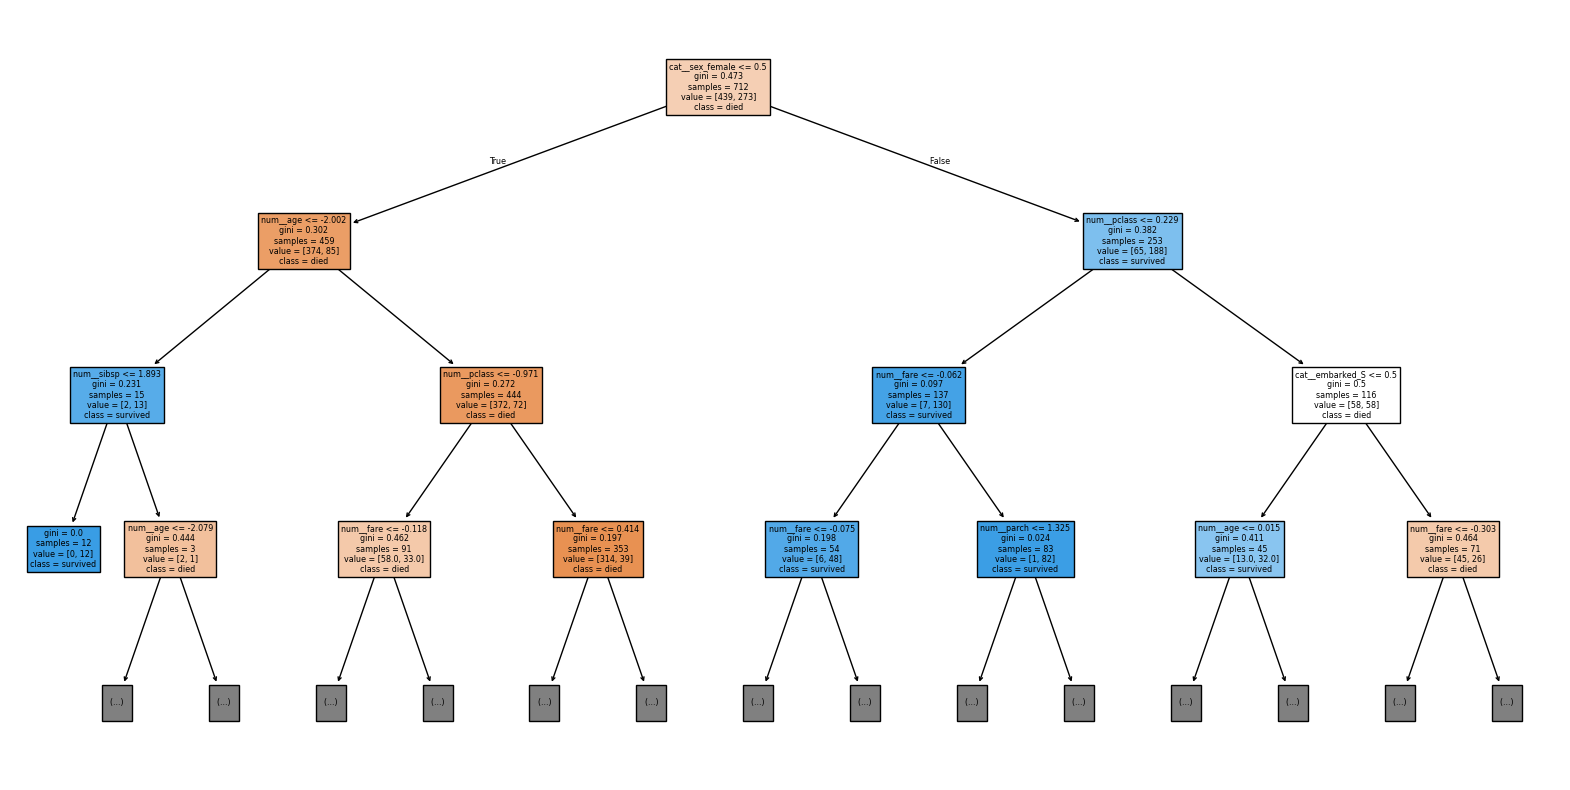

In [3]:
# Decision tree visualization, capped at depth 3 for readability -- the
# fitted tree itself goes deeper, this just shows the top splits.
feature_names = dec_tree.named_steps['preprocessor'].get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(
    dec_tree.named_steps['classifier'],
    feature_names=feature_names,
    class_names=['died', 'survived'],
    filled=True,
    max_depth=3,
)
plt.show()


## Evaluating all three models

Confusion matrices, ROC curves, and the full metric suite (accuracy/precision/recall/F1/AUC) side by side.

/Users/shellzero/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/shellzero/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/shellzero/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/shellzero/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/shellzero/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/shellzero/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


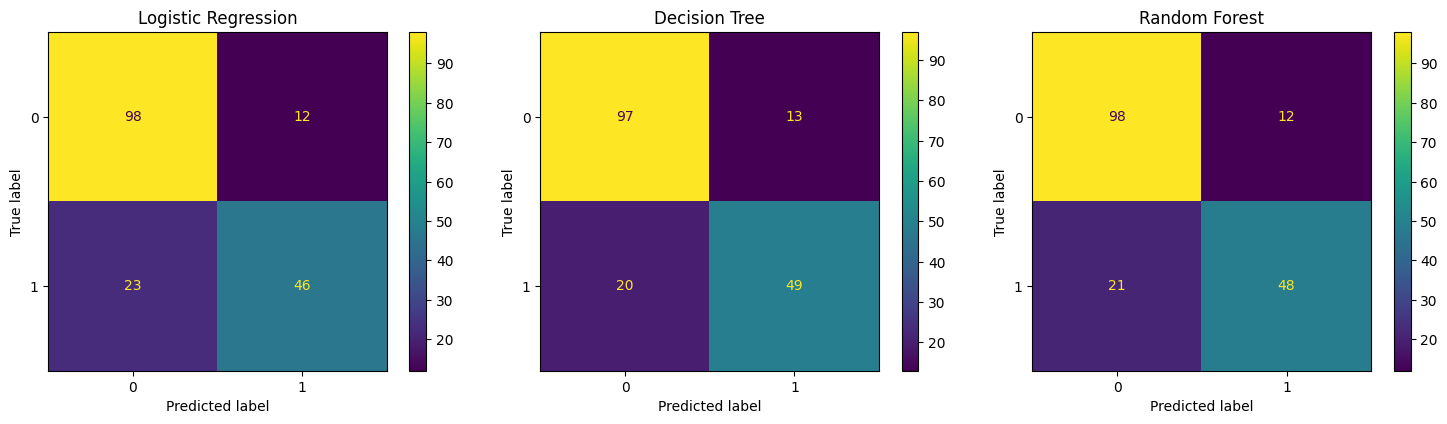

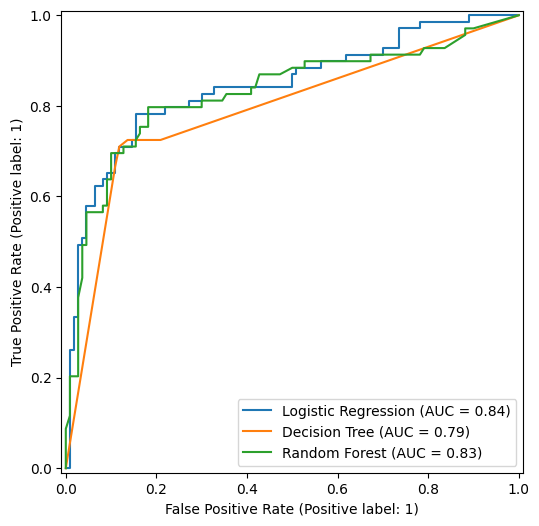

,accuracy,precision,recall,f1,auc
Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.843742
Decision Tree,0.815642,0.790323,0.710145,0.748092,0.790382
Random Forest,0.815642,0.800000,0.695652,0.744186,0.829447


In [4]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, RocCurveDisplay,
)

models = {
    'Logistic Regression': log_reg,
    'Decision Tree': dec_tree,
    'Random Forest': rand_forest,
}

# Full metric suite for every model, plus confusion matrices and ROC curves
# side by side so the three models are directly comparable at a glance.
results = {}
fig_cm, axes_cm = plt.subplots(1, 3, figsize=(15, 4))
fig_roc, ax_roc = plt.subplots(figsize=(6, 6))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # positive-class probability, needed for AUC/ROC

    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_proba),
    }

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes_cm[i])
    axes_cm[i].set_title(name)

    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=ax_roc)

fig_cm.tight_layout()
plt.show()

ax_roc.plot([0, 1], [0, 1], linestyle='--', color='gray')  # random-guess baseline for reference
ax_roc.set_title('ROC curves')
plt.show()

comparison_table = pd.DataFrame(results).T
comparison_table


## Imbalance handling comparison

Baseline vs. `class_weight='balanced'` vs. SMOTE (training fold only), using Random Forest as the test case.

In [5]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print(y_train.value_counts(normalize=True))

# (b) class_weight='balanced' -- reweights the loss so the minority class
# (survived) counts for more during training, no resampling involved.
rf_balanced = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42)),
])
rf_balanced.fit(X_train, y_train)
y_pred_balanced = rf_balanced.predict(X_test)

# (c) SMOTE applied only to the training fold, inside an imblearn Pipeline
# so it runs after preprocessing but is automatically skipped at predict
# time -- fitting SMOTE on the test set (or the full dataset) would leak
# synthetic signal from the test labels into training.
rf_smote = ImbPipeline([
    ('preprocessor', clone(preprocessor)),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42)),
])
rf_smote.fit(X_train, y_train)
y_pred_smote = rf_smote.predict(X_test)

imbalance_results = {
    'baseline': results['Random Forest'],  # reuse Task 10's metrics -- same model/config, no imbalance handling
    'class_weight_balanced': {
        'precision': precision_score(y_test, y_pred_balanced),
        'recall': recall_score(y_test, y_pred_balanced),
        'f1': f1_score(y_test, y_pred_balanced),
    },
    'smote': {
        'precision': precision_score(y_test, y_pred_smote),
        'recall': recall_score(y_test, y_pred_smote),
        'f1': f1_score(y_test, y_pred_smote),
    },
}

pd.DataFrame(imbalance_results).T[['precision', 'recall', 'f1']]


survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64


/Users/shellzero/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


,precision,recall,f1
baseline,0.800000,0.695652,0.744186
class_weight_balanced,0.800000,0.695652,0.744186
smote,0.757576,0.724638,0.740741


## Hyperparameter tuning

`GridSearchCV` over the Random Forest's `n_estimators`/`max_depth`/`max_features`, scored on F1.

In [6]:
from sklearn.model_selection import GridSearchCV

# oob_score=True must be set at construction time -- it's not something you
# can turn on after the fact, and the OOB score only gets populated if it
# was requested up front.
rf_for_tuning = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', RandomForestClassifier(oob_score=True, random_state=42)),
])

param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 5, 10],
    'classifier__max_features': ['sqrt', 'log2'],
}

# 5-fold CV scored on F1 (not accuracy) since the classes are imbalanced.
grid_search = GridSearchCV(rf_for_tuning, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("OOB score:", grid_search.best_estimator_.named_steps['classifier'].oob_score_)


Best params: {'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}
OOB score: 0.8258426966292135


## Regression side-task: predicting fare

Same dataset, different target — a linear regression predicting `fare`, plus a check for heteroscedasticity in the residuals.

MAE: 20.90, RMSE: 30.53, R2: 0.398, Adjusted R2: 0.362


/Users/shellzero/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/shellzero/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/shellzero/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


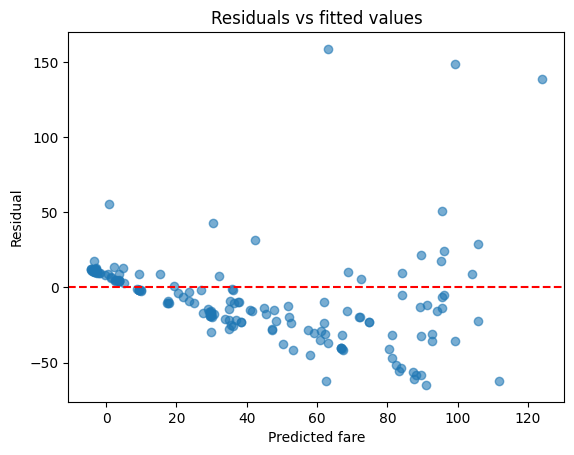

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Regression side-task: predict fare instead of survived. survived is
# included as a feature here (it's the classification target, not this
# task's target), on the theory that survival status correlates with cabin
# class/location and therefore with what was paid.
reg_features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked', 'survived']
X_reg = df[reg_features]
y_reg = df['fare']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_numeric = ['pclass', 'age', 'sibsp', 'parch', 'survived']
reg_categorical = ['sex', 'embarked']

reg_preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), reg_numeric),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]), reg_categorical),
])

linreg_pipeline = Pipeline([
    ('preprocessor', reg_preprocessor),
    ('regressor', LinearRegression()),
])
linreg_pipeline.fit(X_train_reg, y_train_reg)

y_pred_reg = linreg_pipeline.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = root_mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

# Adjusted R2 penalizes R2 for the number of predictors (p), so it doesn't
# automatically go up just from adding more features -- n is the test-set
# size, p is the transformed (post-one-hot) feature count.
n = len(y_test_reg)
p = linreg_pipeline.named_steps['preprocessor'].transform(X_test_reg).shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.3f}, Adjusted R2: {adjusted_r2:.3f}")

residuals = y_test_reg - y_pred_reg
plt.scatter(y_pred_reg, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted fare')
plt.ylabel('Residual')
plt.title('Residuals vs fitted values')
plt.show()


In [8]:
# Heteroscedasticity check: bin predictions and look at how residual spread
# changes across bins. A roughly constant std across bins would mean
# homoscedastic errors; a clear trend (as seen here) means the model's
# reliability itself depends on the predicted value.
resid_df = pd.DataFrame({'predicted_fare': y_pred_reg, 'residual': residuals.values})
resid_df['fare_bin'] = pd.cut(resid_df['predicted_fare'], bins=[-100, 0, 20, 40, 60, 1000])
print(resid_df.groupby('fare_bin')['residual'].std())


fare_bin
(-100, 0]      1.379309
(0, 20]       11.550307
(20, 40]      12.522909
(40, 60]      16.734348
(60, 1000]    47.723758
Name: residual, dtype: float64


/var/folders/4h/clk579xd0792tg0hyxt5ynd80000gn/T/ipykernel_15057/4083134024.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(resid_df.groupby('fare_bin')['residual'].std())


## Final comparison and recommendation

Adding the tuned Random Forest into the classification table, keeping regression metrics in their own table since the two aren't on comparable scales. Write-up of which model I'd actually deploy is in the README.

In [9]:
# Add the tuned Random Forest into the same results dict/table used for the
# three baseline classifiers, so the final comparison table has all four.
y_pred_tuned = grid_search.best_estimator_.predict(X_test)
y_proba_tuned = grid_search.best_estimator_.predict_proba(X_test)[:, 1]

results['Random Forest (tuned)'] = {
    'accuracy': accuracy_score(y_test, y_pred_tuned),
    'precision': precision_score(y_test, y_pred_tuned),
    'recall': recall_score(y_test, y_pred_tuned),
    'f1': f1_score(y_test, y_pred_tuned),
    'auc': roc_auc_score(y_test, y_proba_tuned),
}

classification_table = pd.DataFrame(results).T
classification_table


,accuracy,precision,recall,f1,auc
Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.843742
Decision Tree,0.815642,0.790323,0.710145,0.748092,0.790382
Random Forest,0.815642,0.800000,0.695652,0.744186,0.829447
Random Forest (tuned),0.815642,0.875000,0.608696,0.717949,0.846179


In [10]:
# Kept as its own table rather than merged into classification_table --
# classification and regression metrics are on different scales and aren't
# directly comparable numbers.
regression_table = pd.DataFrame({
    'Linear Regression': {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Adjusted R2': adjusted_r2}
}).T
regression_table


,MAE,RMSE,R2,Adjusted R2
Linear Regression,20.897718,30.532803,0.397548,0.361688


## Saving the pipeline

The fitted preprocessing + tuned Random Forest, saved and reloaded as one object so it works end-to-end on raw input.

In [11]:
import joblib

# Save the fitted preprocessing + tuned Random Forest together as one
# object, not the bare estimator -- that's what makes it usable end-to-end
# on raw input later (the loaded pipeline still has to impute/encode/scale
# before it can predict).
joblib.dump(grid_search.best_estimator_, 'best_titanic_pipeline.joblib')

loaded_pipeline = joblib.load('best_titanic_pipeline.joblib')

sample_raw = X_test.iloc[:5]  # raw, unprocessed rows -- original categorical strings, possible NaNs
print("loaded:", loaded_pipeline.predict(sample_raw))
print("original:", grid_search.best_estimator_.predict(sample_raw))


loaded: [0 0 0 0 1]
original: [0 0 0 0 1]
